In [24]:
from pathlib import Path
from collections import Counter
import statistics
import matplotlib.pyplot as plt
import string
import numpy as np

In [3]:
# Exact project location
project_dir = Path(r"C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1")

# Correct folder paths
data_dir = project_dir / "task1_llm" / "data"
outputs_dir = project_dir / "task1_llm" / "Samruddhi" / "outputs"

outputs_dir.mkdir(parents = True, exist_ok = True)

train_file = data_dir / "tinystories_train_100k.txt"
val_file = data_dir / "tinystories_val_10k.txt"

In [4]:
def load_stories(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        return [line.strip() for line in file if line.strip()]


train_stories = load_stories(train_file)
val_stories = load_stories(val_file)

train_lengths = [len(story) for story in train_stories]
val_lengths = [len(story) for story in val_stories]

train_word_counts = [len(story.split()) for story in train_stories]
val_word_counts = [len(story.split()) for story in val_stories]

In [5]:
all_train_text = " ".join(train_stories)
character_counts = Counter(all_train_text)

In [6]:
print(f"Training stories: {len(train_stories):,}")
print(f"Validation stories: {len(val_stories):,}")

Training stories: 99,983
Validation stories: 10,000


In [7]:
print(f"\nTraining total characters: {sum(train_lengths):,}")
print(f"Validation total characters: {sum(val_lengths):,}")


Training total characters: 88,306,740
Validation total characters: 9,056,150


In [8]:
print(f"Training average characters: {statistics.mean(train_lengths):,.2f}")
print(f"Training median characters: {statistics.median(train_lengths):,.2f}")
print(f"Training shortest story: {min(train_lengths):,}")
print(f"Training longest story: {max(train_lengths):,}")

Training average characters: 883.22
Training median characters: 782.00
Training shortest story: 205
Training longest story: 4,540


In [9]:
print(f"Training average words: {statistics.mean(train_word_counts):,.2f}")
print(f"Training median words: {statistics.median(train_word_counts):,.2f}")
print(f"Training shortest story: {min(train_word_counts):,}")
print(f"Training longest story: {max(train_word_counts):,}")

Training average words: 172.78
Training median words: 152.00
Training shortest story: 43
Training longest story: 879


In [10]:
print(f"Number of unique training characters: {len(character_counts):,}")
print("\nMost frequent characters:")
for character, count in character_counts.most_common(20):
    print(repr(character), "->", f"{count:,}")


Number of unique training characters: 109

Most frequent characters:
' ' -> 17,775,335
'e' -> 8,435,915
'a' -> 5,947,114
't' -> 5,540,009
'o' -> 4,607,482
'h' -> 4,344,883
'n' -> 4,127,062
'i' -> 3,796,212
'd' -> 3,781,463
's' -> 3,658,165
'r' -> 3,217,630
'l' -> 2,736,521
'y' -> 2,001,065
'w' -> 1,751,213
'm' -> 1,745,164
'.' -> 1,678,660
'u' -> 1,672,069
'g' -> 1,298,848
'c' -> 1,278,158
'p' -> 1,240,947


In [11]:
print(f"Empty training stories: {sum(len(story) == 0 for story in train_stories)}")
print(f"Empty validation stories: {sum(len(story) == 0 for story in val_stories)}")

Empty training stories: 0
Empty validation stories: 0


### Story character-length distribution

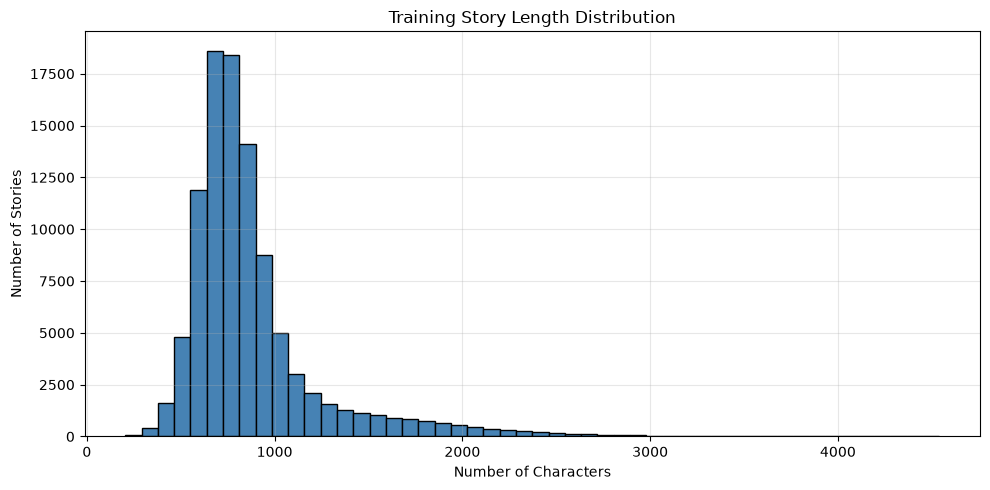

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(train_lengths, bins=50, color="steelblue", edgecolor="black")
plt.title("Training Story Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Stories")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(outputs_dir / "story_length_distribution.png", dpi=150)
plt.show()

- Most TinyStories contain approximately 500–900 characters.
- The distribution is right-skewed.

### Word-count distribution

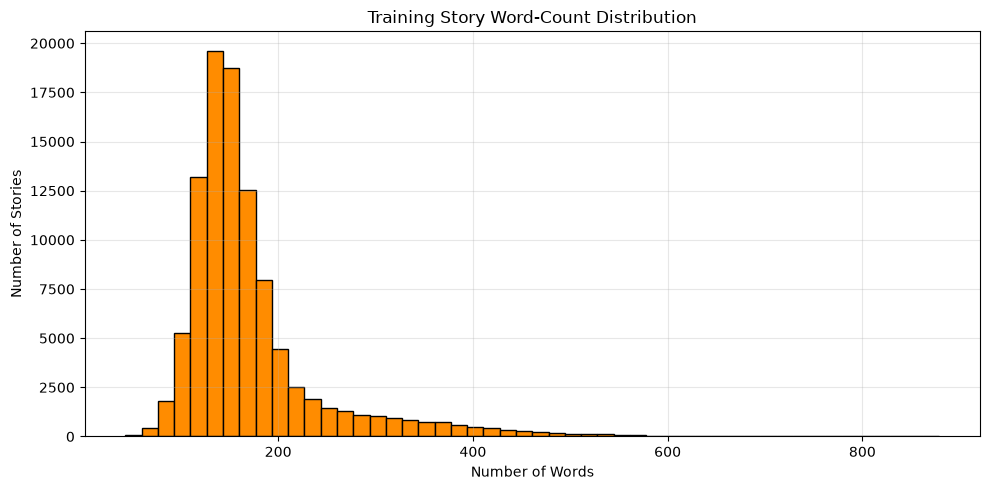

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(train_word_counts, bins=50, color="darkorange", edgecolor="black")
plt.title("Training Story Word-Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Stories")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(outputs_dir / "word_count_distribution.png", dpi=150)
plt.show()

- Most TinyStories contain approximately **100–200 words**.
- The highest concentration is around **120–160 words**.
- The distribution is **right-skewed**.
- A small number of stories contain more than **300 words**.
- Some longer stories extend to approximately **800–900 words**.
- This confirms that most stories are short, but the dataset also includes a few longer examples.
- Fixed-length character sequences will help divide both short and long stories into manageable training blocks.

### Most frequent characters

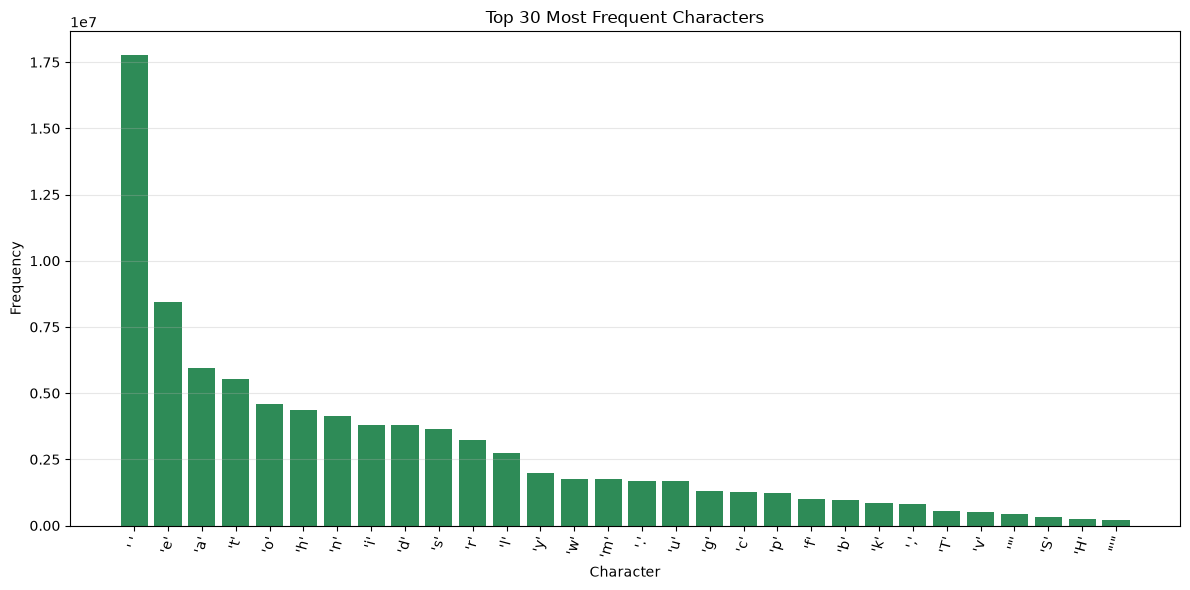

In [15]:
top_characters = character_counts.most_common(30)

labels = [repr(character) for character, _ in top_characters]
counts = [count for _, count in top_characters]

plt.figure(figsize=(12, 6))
plt.bar(labels, counts, color="seagreen")
plt.title("Top 30 Most Frequent Characters")
plt.xlabel("Character")
plt.ylabel("Frequency")
plt.xticks(rotation=75)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(outputs_dir / "top_30_character_frequency.png", dpi=150)
plt.show()

- The **space character** is the most frequent character in the training data.
- The next most frequent characters are **`e`**, **`a`**, **`t`**, **`o`**, and **`h`**.
- These are common because they frequently appear in English words.
- Characters such as **`n`**, **`r`**, **`d`**, **`s`**, and **`i`** also occur very often.
- Less frequent characters include punctuation marks, uppercase letters, and uncommon symbols.
- The frequency decreases gradually from common characters to rare characters.
- This confirms that a **character-level vocabulary** is suitable for the TinyStories dataset.
- The model will assign each unique character an integer ID based on this vocabulary.

### Training vs. validation story-length comparison

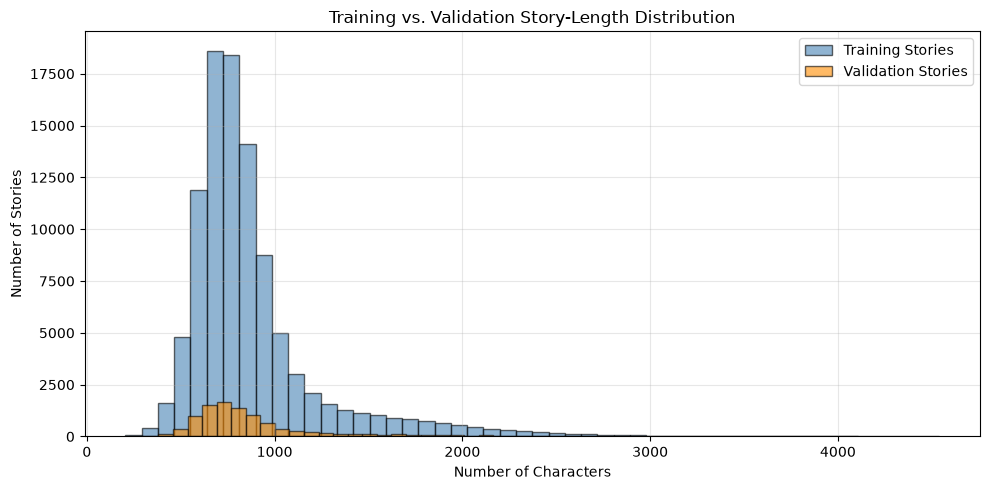

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(
    train_lengths,
    bins=50,
    alpha=0.6,
    label="Training Stories",
    color="steelblue",
    edgecolor="black"
)

plt.hist(
    val_lengths,
    bins=50,
    alpha=0.6,
    label="Validation Stories",
    color="darkorange",
    edgecolor="black"
)

plt.title("Training vs. Validation Story-Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Stories")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

comparison_plot = outputs_dir / "train_vs_validation_story_length.png"
plt.savefig(comparison_plot, dpi=150)
plt.show()

- Both training and validation sets have a similar story-length pattern.
- Most stories in both sets contain approximately **500–900 characters**.
- Both distributions are **right-skewed**, with a small number of longer stories.
- The validation distribution follows the overall shape of the training distribution.
- The training bars are taller because the training set contains **100,000 stories**, while validation contains only **10,000 stories**.
- Therefore, the different bar heights do not indicate a major difference in story length.
- The similar distributions suggest that the validation set is reasonably representative of the training set.
- The same fixed-length sequence strategy can be applied to both datasets.

### Cumulative story-length distribution

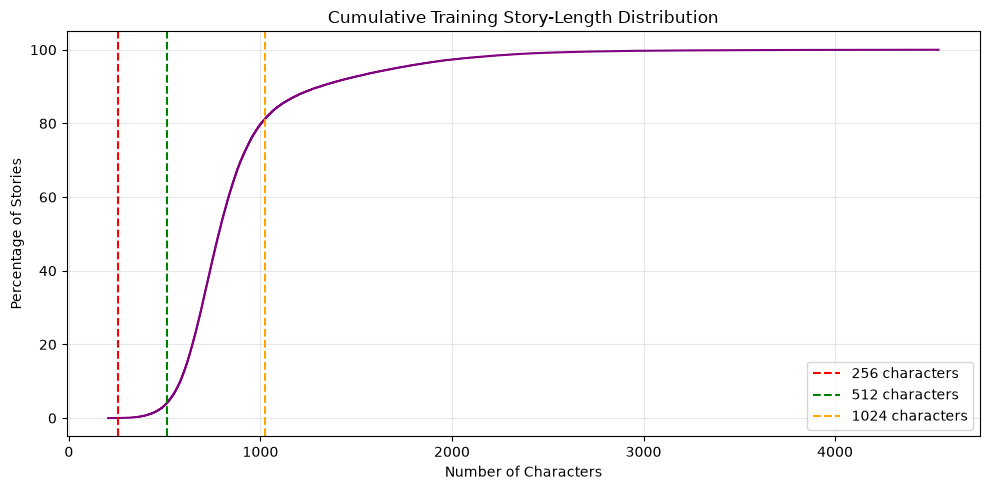

In [18]:
sorted_lengths = sorted(train_lengths)
cumulative_percent = [
    (index + 1) / len(sorted_lengths) * 100
    for index in range(len(sorted_lengths))
]

plt.figure(figsize=(10, 5))
plt.plot(sorted_lengths, cumulative_percent, color="purple")
plt.axvline(256, color="red", linestyle="--", label="256 characters")
plt.axvline(512, color="green", linestyle="--", label="512 characters")
plt.axvline(1024, color="orange", linestyle="--", label="1024 characters")
plt.title("Cumulative Training Story-Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Percentage of Stories")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(outputs_dir / "cumulative_story_length_distribution.png", dpi=150)
plt.show()

- This plot shows the percentage of stories that are shorter than a given number of characters.
- At **256 characters**, only a very small percentage of stories are completely covered.
- At **512 characters**, only about **5%** of stories are covered.
- At **1,024 characters**, approximately **80–82%** of stories are covered.
- The curve rises quickly between approximately **500 and 1,000 characters**, meaning most stories fall in this range.
- A small number of stories are much longer, extending beyond **2,000 characters**.
- A block size of **1,024 characters** would cover most stories, while longer stories would need to be divided into multiple training blocks.

### Training vs. validation box plot

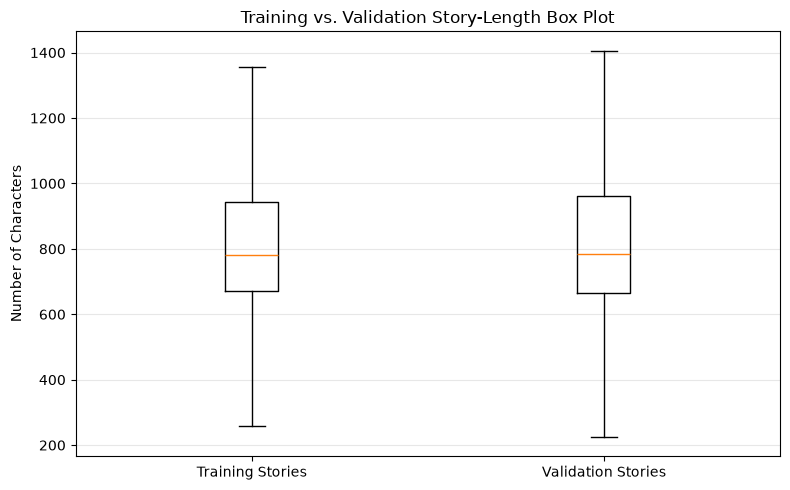

In [19]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [train_lengths, val_lengths],
    tick_labels=["Training Stories", "Validation Stories"],
    showfliers=False
)
plt.title("Training vs. Validation Story-Length Box Plot")
plt.ylabel("Number of Characters")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(outputs_dir / "train_vs_validation_boxplot.png", dpi=150)
plt.show()

- Training and validation story lengths have very similar distributions.
- The median story length is approximately **780 characters** for both datasets.
- Most stories fall between approximately **650 and 950 characters**.
- The whiskers show that story lengths range roughly from **200–250 to 1,350–1,400 characters**.
- The similar box shapes suggest that the validation set is representative of the training set.
- There is no major distribution difference between training and validation data.
- `showfliers=False` means individual outlier points are hidden in this plot.

### Words versus characters scatter plot

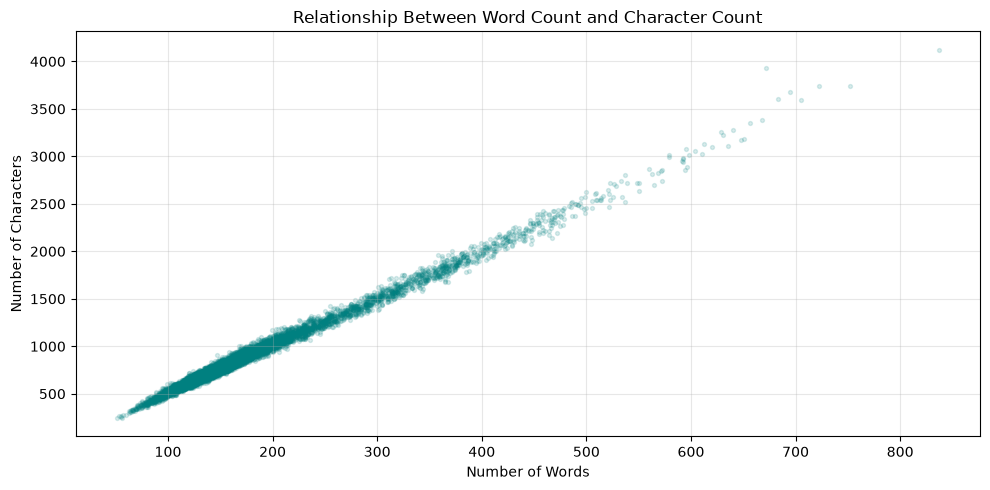

In [20]:
sample_word_counts = train_word_counts[::10]
sample_character_counts = train_lengths[::10]

plt.figure(figsize=(10, 5))
plt.scatter(
    sample_word_counts,
    sample_character_counts,
    alpha=0.15,
    s=8,
    color="teal"
)
plt.title("Relationship Between Word Count and Character Count")
plt.xlabel("Number of Words")
plt.ylabel("Number of Characters")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(outputs_dir / "words_vs_characters.png", dpi=150)
plt.show()

- There is a strong positive relationship between word count and character count.
- Stories with more words generally contain more characters.
- The points form a narrow upward pattern, showing the relationship is consistent.
- A few longer stories appear as outliers with more than 600 words and 3,000 characters.
- This confirms that word count can be used as a good estimate of story length.
- The model’s fixed-length sequences should be based on characters or tokens because story lengths vary significantly.

### Punctuation frequency plot

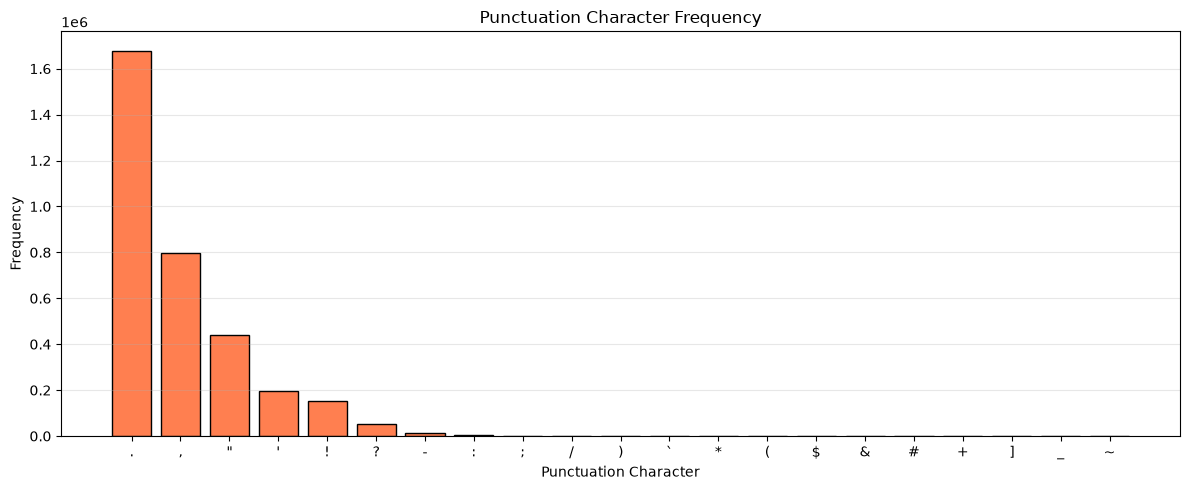

In [21]:
punctuation_counts = Counter(
    character
    for character in all_train_text
    if character in string.punctuation
)

punctuation_items = punctuation_counts.most_common()
punctuation_labels = [character for character, _ in punctuation_items]
punctuation_values = [count for _, count in punctuation_items]

plt.figure(figsize=(12, 5))
plt.bar(
    punctuation_labels,
    punctuation_values,
    color="coral",
    edgecolor="black"
)
plt.title("Punctuation Character Frequency")
plt.xlabel("Punctuation Character")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(outputs_dir / "punctuation_frequency.png", dpi=150)
plt.show()

- The **period (`.`)** is the most frequent punctuation character.
- The **comma (`,`)** is the second most frequent.
- The **apostrophe (`'`)** also appears frequently because of contractions such as *don’t*, *can’t*, and *it’s*.
- Other punctuation marks, such as **question marks, hyphens, quotation marks, and exclamation marks**, occur less often.
- The frequency decreases significantly after the most common punctuation marks.
- This indicates that the dataset mainly contains simple English stories with regular sentence endings and dialogue.
- Punctuation should be preserved during character-level tokenization because it helps the model learn sentence boundaries, questions, dialogue, and word structure.

### Uppercase versus lowercase characters

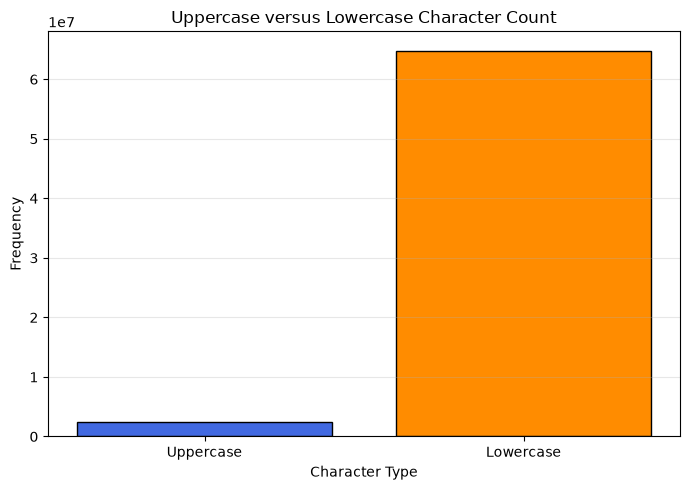

In [22]:
uppercase_count = sum(character.isupper() for character in all_train_text)
lowercase_count = sum(character.islower() for character in all_train_text)

case_labels = ["Uppercase", "Lowercase"]
case_values = [uppercase_count, lowercase_count]

plt.figure(figsize=(7, 5))
plt.bar(
    case_labels,
    case_values,
    color=["royalblue", "darkorange"],
    edgecolor="black"
)
plt.title("Uppercase versus Lowercase Character Count")
plt.xlabel("Character Type")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(outputs_dir / "uppercase_vs_lowercase.png", dpi=150)
plt.show()

- Lowercase characters occur much more frequently than uppercase characters.
- The dataset contains approximately **64 million lowercase characters**.
- It contains approximately **2–3 million uppercase characters**.
- This is expected because most English words are written in lowercase.
- Uppercase characters mainly appear at the beginning of sentences and in proper names.

### Story-length percentile analysis

In [25]:
percentile_values = [25, 50, 75, 90, 95, 99]
length_percentiles = np.percentile(train_lengths, percentile_values)

print("STORY-LENGTH PERCENTILES")
print("=" * 50)

for percentile, length in zip(percentile_values, length_percentiles):
    print(f"{percentile}th percentile: {length:.0f} characters")

STORY-LENGTH PERCENTILES
25th percentile: 670 characters
50th percentile: 782 characters
75th percentile: 944 characters
90th percentile: 1310 characters
95th percentile: 1707 characters
99th percentile: 2409 characters
